<a href="https://colab.research.google.com/github/reezyhudson865/AI_Projects/blob/main/RHudson_BOW_TFIDF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Challenge Lab Assignment: Text Normalization, BOW, TF-IDF, and Document Similarity
### Using U.S. Presidential Inaugural Speeches

> **Course:** AI 102 — Natural Language-Based Programming Techniques  
> **Your Name:** Reezy Hudson  
> **Due Date:** 03/05/2026



The following notebook follows a lab completed in an undergrad Applied AI class at UT-Knoxville in the Spring 2026 semester. It follows BOW and TF-IDF of U.S. presidential inaugural speeches. The lab follows a model outlined by the professor. All rights reserved.

In [ ]:
!pip install scipy --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import inaugural
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from scipy.cluster.hierarchy import dendrogram, linkage

nltk.download('inaugural')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')

print('Setup complete.')

Setup complete.


[nltk_data] Downloading package inaugural to
[nltk_data]     /Users/reesehudson/nltk_data...
[nltk_data]   Package inaugural is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/reesehudson/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/reesehudson/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/reesehudson/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/reesehudson/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
speech_ids = inaugural.fileids()

#Print the total number of speeches
print(f"Total speeches: {len(speech_ids)}")

#Print the first 5 speech IDs
print(f"First 5: {speech_ids[:5]}")

#Print the last 5 speech IDs
print(f"Last 5:  {speech_ids[-5:]}")

Total speeches: 60
First 5: ['1789-Washington.txt', '1793-Washington.txt', '1797-Adams.txt', '1801-Jefferson.txt', '1805-Jefferson.txt']
Last 5:  ['2009-Obama.txt', '2013-Obama.txt', '2017-Trump.txt', '2021-Biden.txt', '2025-Trump.txt']


In [ ]:
#Load Kennedy's speech
kennedy_raw = inaugural.raw('1961-Kennedy.txt')

#Print the first 600 characters of kennedy_raw
print("--- First 600 characters of Kennedy 1961 (raw) ---")
print(kennedy_raw[:600])

--- First 600 characters of Kennedy 1961 (raw) ---
Vice President Johnson, Mr. Speaker, Mr. Chief Justice, President Eisenhower, Vice President Nixon, President Truman, reverend clergy, fellow citizens, we observe today not a victory of party, but a celebration of freedom -- symbolizing an end, as well as a beginning -- signifying renewal, as well as change. For I have sworn I before you and Almighty God the same solemn oath our forebears l prescribed nearly a century and three quarters ago.

The world is very different now. For man holds in his mortal hands the power to abolish all forms of human poverty and all forms of human life. And yet t


In [ ]:
#Initialize
english_stopwords = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

english_stopwords.update({"must"})


def normalize_document(doc):
    """
    Normalize a single document for NLP analysis.

    Parameters:
    - doc (str): A raw text string

    Returns:
    - str: A cleaned, preprocessed string ready for vectorization
    """


    #Convert doc to lowercase
    doc = doc.lower()

    #Tokenize
    tokens = word_tokenize(doc)

    #Keep only real words
    tokens = [t for t in tokens if t.isalpha()]

    #Remove stop words
    tokens = [t for t in tokens if t not in english_stopwords]

    #Lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    #Rejoin tokens into a single string
    return ' '.join(tokens)


#Test
test_sentence = "Fellow citizens, our nations must pursue freedom and justice for all people!"
print("Original:  ", test_sentence)
print("Normalized:", normalize_document(test_sentence))

Original:   Fellow citizens, our nations must pursue freedom and justice for all people!
Normalized: fellow citizen nation pursue freedom justice people




Converting all text to lowercase first ensures all words are treated the same as the same token. Then punctuation and stopwords are removed to ensure smooth scanning. This is important to do in this order because inconsistent capitalization could create more tokens than necessary.

In [ ]:
print("Normalizing all speeches — this may take about 20 seconds...")

#Build normalized_speeches
normalized_speeches = [
    normalize_document(inaugural.raw(speech_id))
    for speech_id in speech_ids
]

print(f"Done. {len(normalized_speeches)} speeches normalized.")

#Verify
kennedy_index = speech_ids.index('1961-Kennedy.txt')
print("\nKennedy RAW (first 200 chars):")
print(inaugural.raw('1961-Kennedy.txt')[:200])
print("\nKennedy NORMALIZED (first 200 chars):")
print(normalized_speeches[kennedy_index][:200])

Normalizing all speeches — this may take about 20 seconds...
Done. 60 speeches normalized.

Kennedy RAW (first 200 chars):
Vice President Johnson, Mr. Speaker, Mr. Chief Justice, President Eisenhower, Vice President Nixon, President Truman, reverend clergy, fellow citizens, we observe today not a victory of party, but a c

Kennedy NORMALIZED (first 200 chars):
vice president johnson speaker chief justice president eisenhower vice president nixon president truman reverend clergy fellow citizen observe today victory party celebration freedom symbolizing end w


In [ ]:
#Create a CountVectorizer object.
bow_vectorizer = CountVectorizer(max_features=2000)

#Fit and transform normalized_speeches to produce bow_matrix.
bow_matrix = bow_vectorizer.fit_transform(normalized_speeches)

bow_vocabulary = bow_vectorizer.get_feature_names_out()

print(f"BOW matrix shape: {bow_matrix.shape}  ({bow_matrix.shape[0]} speeches x {bow_matrix.shape[1]} words)")

BOW matrix shape: (60, 2000)  (60 speeches x 2000 words)


In [ ]:
#Create labels
speech_labels = [sid.replace('.txt', '') for sid in speech_ids]

#Convert bow_matrix into a pandas DataFrame.
bow_df = pd.DataFrame(bow_matrix.toarray(), index=speech_labels, columns=bow_vocabulary)

print("BOW matrix — first 8 speeches, first 8 words (raw word counts):")
print(bow_df.iloc[:8, :8])

BOW matrix — first 8 speeches, first 8 words (raw word counts):
                 abandon  abiding  ability  able  abroad  absolute  abundant  \
1789-Washington        0        0        0     0       0         0         0   
1793-Washington        0        0        0     0       0         0         0   
1797-Adams             0        0        0     0       1         0         0   
1801-Jefferson         1        0        0     0       1         1         0   
1805-Jefferson         0        0        0     1       0         0         0   
1809-Madison           0        0        0     0       0         0         0   
1813-Madison           0        0        0     0       0         0         0   
1817-Monroe            0        0        0     2       1         0         2   

                 abuse  
1789-Washington      0  
1793-Washington      0  
1797-Adams           1  
1801-Jefferson       2  
1805-Jefferson       2  
1809-Madison         0  
1813-Madison         0  
1817-Monroe    

In [ ]:
#Select Kennedy's(1961-Kennedy) row
kennedy_bow_row = bow_df.loc['1961-Kennedy']

#Sort from highest to lowest count and keep the top 15
kennedy_bow_top = kennedy_bow_row.sort_values(ascending=False).head(15)

print("Kennedy 1961 — Top 15 most frequent words (raw counts):")
for word, count in kennedy_bow_top.items():
    print(f"  {word:<20} {int(count)}")

Kennedy 1961 — Top 15 most frequent words (raw counts):
  let                  16
  side                 8
  world                8
  power                7
  new                  7
  nation               7
  pledge               7
  citizen              5
  ask                  5
  free                 5
  shall                5
  generation           4
  war                  4
  arm                  4
  first                4




The top words of Kennedy's speech are words you would find across several speeches. I would think the words would be more complex, however BOW models only remove extremely basic english words, so words like "let" or "new" would easily slip through. TF-IDF would fix this by assigning higher weight to words that appear in one speech that rarely appear in other speeches, which allows unique words to be more visible in analysis.

In [ ]:
tfidf_vectorizer = TfidfVectorizer(stop_words=None, max_features=2000)

#Fit and transform normalized_speeches to produce tfidf_matrix
tfidf_matrix = tfidf_vectorizer.fit_transform(normalized_speeches)

#Retrieve the vocabulary
vocabulary = tfidf_vectorizer.get_feature_names_out()

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}  ({tfidf_matrix.shape[0]} speeches x {tfidf_matrix.shape[1]} words)")

TF-IDF matrix shape: (60, 2000)  (60 speeches x 2000 words)




The BOW matrix is raw word counts, which is how many times a word appears in a speech. The TF-IDF matrix contains weighted counts that show how often a word appears along with how rare it is in comparison to other speeches. The difference matters for identifying uncommon words because TF-IDF weighs word valye based on rarity, which allows for better comparison.

In [ ]:
#Convert tfidf_matrix into a pandas DataFrame.
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), index=speech_labels, columns=vocabulary)

print("TF-IDF matrix — first 8 speeches, first 8 words:")
print(tfidf_df.iloc[:8, :8].round(4))

TF-IDF matrix — first 8 speeches, first 8 words:
                 abandon  abiding  ability    able  abroad  absolute  \
1789-Washington   0.0000      0.0      0.0  0.0000  0.0000    0.0000   
1793-Washington   0.0000      0.0      0.0  0.0000  0.0000    0.0000   
1797-Adams        0.0000      0.0      0.0  0.0000  0.0227    0.0000   
1801-Jefferson    0.0436      0.0      0.0  0.0000  0.0304    0.0419   
1805-Jefferson    0.0000      0.0      0.0  0.0265  0.0000    0.0000   
1809-Madison      0.0000      0.0      0.0  0.0000  0.0000    0.0000   
1813-Madison      0.0000      0.0      0.0  0.0000  0.0000    0.0000   
1817-Monroe       0.0000      0.0      0.0  0.0365  0.0165    0.0000   

                 abundant   abuse  
1789-Washington    0.0000  0.0000  
1793-Washington    0.0000  0.0000  
1797-Adams         0.0000  0.0265  
1801-Jefferson     0.0000  0.0711  
1805-Jefferson     0.0000  0.0561  
1809-Madison       0.0000  0.0000  
1813-Madison       0.0000  0.0000  
1817-Monroe   

In [ ]:
#Select Kennedy's row from tfidf_df
kennedy_row = tfidf_df.loc['1961-Kennedy']

#Sort the row from highest to lowest score
kennedy_top = kennedy_row.sort_values(ascending=False)

#Keep only the top 15 and drop words with a score of 0
kennedy_top = kennedy_top[kennedy_top > 0].head(15)

print("Kennedy 1961 — Top 15 most distinctive words (TF-IDF scores):")
for word, score in kennedy_top.items():
    print(f"  {word:<20} {score:.4f}")

Kennedy 1961 — Top 15 most distinctive words (TF-IDF scores):
  let                  0.3193
  side                 0.2257
  pledge               0.1778
  final                0.1299
  ask                  0.1296
  dare                 0.1248
  world                0.1240
  new                  0.1159
  power                0.1159
  help                 0.1154
  globe                0.1125
  begin                0.1125
  arm                  0.1081
  nation               0.1016
  poverty              0.1002


In [ ]:
spotlight_speeches = [
    '1789-Washington',
    '1865-Lincoln',
    '1933-Roosevelt',
    '1961-Kennedy',
]

#Loop over spotlight_speeches.
for label in spotlight_speeches:
    top_words = tfidf_df.loc[label].sort_values(ascending=False)
    top_words = top_words[top_words > 0].head(8)

    print(f"\n{label}:")
    for word, score in top_words.items():
        print(f"  {word:<20} {score:.3f}")


1789-Washington:
  every                0.174
  government           0.168
  ought                0.139
  public               0.135
  present              0.131
  peculiarly           0.120
  since                0.115
  qualification        0.114

1865-Lincoln:
  war                  0.353
  god                  0.202
  neither              0.157
  union                0.156
  altogether           0.153
  address              0.146
  pray                 0.141
  cease                0.141

1933-Roosevelt:
  helped               0.268
  leadership           0.229
  discipline           0.146
  emergency            0.136
  national             0.135
  lie                  0.134
  money                0.134
  profit               0.131

1961-Kennedy:
  let                  0.319
  side                 0.226
  pledge               0.178
  final                0.130
  ask                  0.130
  dare                 0.125
  world                0.124
  new                  0.116




Roosevelt's top words including language surrounding the economy. This was most prevalent during his presidency in comparison to others, so it was mentioned more often in his speech only. This tells me that the TF-IDF is measuring the distinctiveness of a word across a large collection.


In [ ]:
#Convert the TF-IDF matrix to a regular array.
tfidf_dense = tfidf_matrix.toarray()

#Build the linkage matrix.
Z = linkage(tfidf_dense, method='ward')

print(f"Linkage matrix shape: {Z.shape}")
print(f"With {len(speech_labels)} speeches, there are {len(speech_labels) - 1} merge steps.")
print("Each row in Z: [group_A, group_B, merge_distance, new_cluster_size]")

Linkage matrix shape: (59, 4)
With 60 speeches, there are 59 merge steps.
Each row in Z: [group_A, group_B, merge_distance, new_cluster_size]




Hierarchical clustering merges 2 at a time, so it takes 59 steps to combine all 60. The four values include the index of the first cluster merge, the index of the second, the distance between them, and the number of observatoins originaly contained in the new cluster.

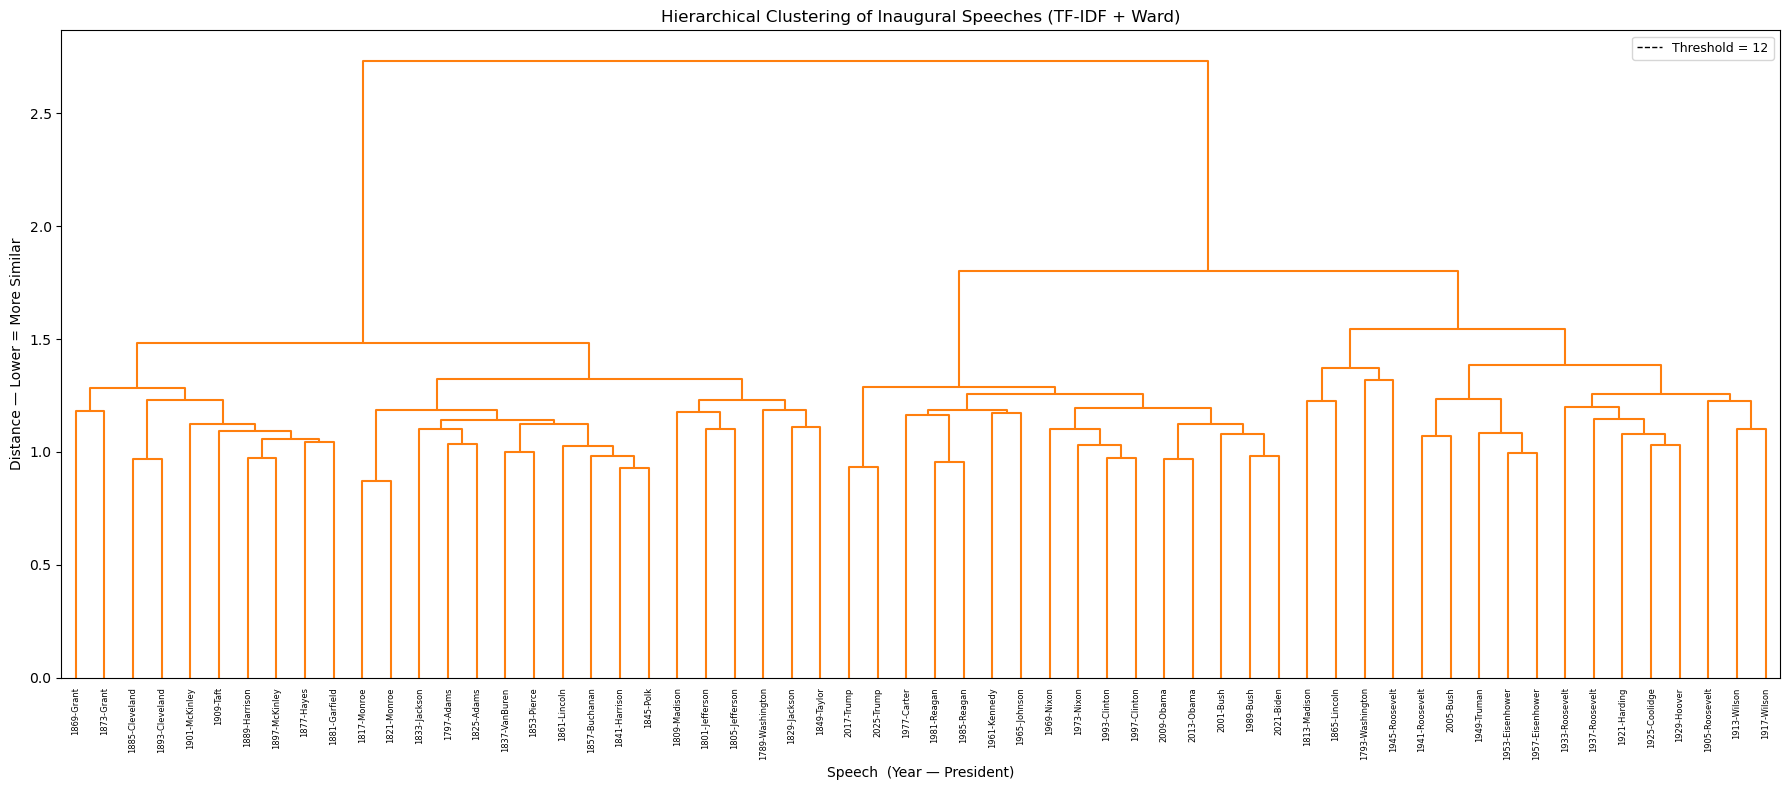

In [ ]:
#chart
fig, ax = plt.subplots(figsize=(18, 8))

color_threshold = 12

dendrogram(
    Z,
    labels=speech_labels,
    leaf_rotation=90,
    color_threshold=color_threshold,
    above_threshold_color='gray',
    ax=ax
)


ax.axhline(y=color_threshold, color='black', linestyle='--', linewidth=1, label=f'Threshold = {color_threshold}')


ax.set_title("Hierarchical Clustering of Inaugural Speeches (TF-IDF + Ward)")


ax.set_xlabel("Speech  (Year — President)")


ax.set_ylabel('Distance — Lower = More Similar')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()



1961-Kennedy and 1965-Johnson merge at a low height. This tells me that they share very similar word choices and talking themes, making their TF-IDF similar. Both speeches were delivered during the Cold War, so they emphasize global leadership and spreading national rhetoric.